# NOVAPAY: FRAUDULENT TRANSACTION DETECTION FOR DIGITAL MONEY TRANSFER

## AUTHOR: INIOLUWA PIRISOLA

### DATA EXPLORATION

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("/content/sample_data/nova_pay_combined.csv")

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [8]:
df.shape

(11400, 26)

In [9]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [11]:
df["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.912544
1,0.087456


### DATA CLEANING

Converting timestamp from object to datetime,
Converting amount_src from object to float

In [12]:
#convert timestamp to datetime
df['timestamp']=pd.to_datetime(df['timestamp'], errors='coerce')

In [13]:
#convert amount_srt to float
df['amount_src']=pd.to_numeric(df['amount_src'], errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11400 non-null  object             
 1   customer_id                11400 non-null  object             
 2   timestamp                  11339 non-null  datetime64[ns, UTC]
 3   home_country               11400 non-null  object             
 4   source_currency            11400 non-null  object             
 5   dest_currency              11400 non-null  object             
 6   channel                    11400 non-null  object             
 7   amount_src                 11396 non-null  float64            
 8   amount_usd                 11095 non-null  float64            
 9   fee                        11105 non-null  float64            
 10  exchange_rate_src_to_dest  11400 non-null  float64            
 11  de

Filling in missing values for targeted columns

Filling in missing values for amount_usd. This calculates exchange rates per currency by selecting non-missing rows in amount_usd and grouping by source currency, then computing the mean of amount_usd/amount_src for each currency and saving the results to a dictionary for easy lookup. The missing values in amount_src are filled by multiplying the values derived for the exchange rate and the source_currency column

In [15]:
#Filling in missing values for amount_usd
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(
    lambda x: (x['amount_usd']/x['amount_src']).mean()).to_dict()

/tmp/ipykernel_3293/1668463050.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(


In [16]:
exchange_rates

{'CAD': 0.7216095926871465,
 'GBP': 1.223441221648679,
 'USD': 0.9838730321259439}

In [17]:
df['amount_usd'] = df.apply(lambda row: row['amount_usd']
                            if pd.notna(row['amount_usd']) else row['amount_src']*exchange_rates.get(row['source_currency'], 1),axis=1)

In [18]:
# To view rows where amount_src is null, filter rows
null_rows = df[df['amount_src'].isnull()]

# Display results
print(null_rows)

# Optional: count how many
print("Number of null rows in amount_src:", null_rows.shape[0])

                            transaction_id  \
4812  95df4052-29be-470f-87f9-61e5173370b2   
8036  5569192e-3bf1-47e3-9723-d63c3dd30cad   
8878  19a415c4-05b3-40b5-ad6d-e7d34247e050   
9444  99a53933-5876-47df-ad3e-7976b48c01b4   

                               customer_id                        timestamp  \
4812  7041b9c1-3719-4ca8-9a6b-811b47cea6c0 2024-03-12 08:48:06.468549+00:00   
8036  66c71a44-d07c-4a20-a576-0a377193bf6b 2025-03-09 12:04:34.468549+00:00   
8878  6d0d9b27-fa26-45f8-93b1-2df29d182d9c 2025-06-04 08:02:23.468549+00:00   
9444  6d0d9b27-fa26-45f8-93b1-2df29d182d9c 2025-08-06 15:30:28.468549+00:00   

     home_country source_currency dest_currency channel  amount_src  \
4812           UK             GBP           CAD  mobile         NaN   
8036           US             USD           USD     web         NaN   
8878           US             USD           INR     ATM         NaN   
9444           US             USD           CAD  mobile         NaN   

      amount_usd 

In [19]:
df.iloc[4811:4815]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
4811,db820cfc-7251-4f26-9ace-556250658e43,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2024-03-12 05:52:08.468549+00:00,US,USD,INR,mobile,439.16,439.16,7.86,...,0.129,enhanced,257,0.894,0,0.257,0,0,0.0,0
4812,95df4052-29be-470f-87f9-61e5173370b2,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2024-03-12 08:48:06.468549+00:00,UK,GBP,CAD,mobile,NaN,12498.57,-1.00,...,1.200,standard,4,-0.100,0,0.407,-1,0,0.0,0
4813,d4002b56-f3f5-426b-95f9-1191a6dc48c0,95de1ea4-0f12-4380-b781-16b6a490bebd,2024-03-12 12:26:57.468549+00:00,US,USD,USD,mobile,197.66,197.66,3.10,...,0.283,standard,1058,0.923,0,0.139,0,0,0.0,0
4814,4dd8f93c-326c-446b-b2c5-6f81701780d0,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2024-03-12 12:46:39.468549+00:00,US,USD,GBP,mobile,170.62,170.62,3.09,...,0.373,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [20]:
# Dropping the rows where amount_src is null since the values are too high and will cause an imbalance
df.dropna(subset=['amount_src'], inplace=True)

In [21]:
df.shape

(11396, 26)

In [22]:
# Filling in missing values for the fee column.
# This is done based on the median for the channel feature since fee is dependent on channel
if 'fee' in df.columns:
  if 'channel' in df.columns:
        df['fee'] = df.groupby('channel')['fee']\
              .transform(lambda x: x.fillna(x.median()))
        df['fee'] = df['fee'].fillna(df['fee'].median())

In [23]:
# Filling in the ip_country values
# This is done by using the corresponding home country
if 'ip_country' in df.columns and 'home_country' in df.columns:
  df['ip_country'] = df['ip_country'].fillna(df['home_country'])

In [24]:
# Filling in the missing values in kyc_tier with the mode
if 'kyc_tier' in df.columns:
  mode_kyc = df['kyc_tier'].mode().iloc[0] if not df['kyc_tier'].mode().empty else 'standard'
  df['kyc_tier'] = df['kyc_tier'].fillna(mode_kyc)

In [25]:
# Filling in the missing values in device_trust_score using the group's median value
if 'device_trust_score' in df.columns:
    if {'new_device','kyc_tier'}.issubset(df.columns):
        df['device_trust_score'] = df.groupby(['new_device','kyc_tier'])['device_trust_score'].transform(lambda x: x.fillna(x.median()))
    df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

In [26]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,61
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


Dropping rows with missing values where replacements cannot be applied

In [27]:
df.dropna(inplace= True)

In [28]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


Dropping duplicated rows - 194 rows were dropped

In [29]:
# Checking for duplicated rown and dropping duplicates
df.duplicated().sum()

np.int64(194)

In [30]:
df.drop_duplicates(inplace=True)

### Sanity Checks for the dataset

This section lists essential sanity checks to validate the dataset after cleaning and imputation

1. Check for invalid numeric values, including negative values in monetary, risk, trust or velocity fields and validate the user age in days is not negative
2. Verify currency-related logic and ensure there are no negative values and that the derived exchange rates fall within reasonable range
3. Validate timestamp integrity and confirm no transaction timestamps occur in the future
4. Review location consistency to ensure the counts in location_mismatch was generated corrrectly and the country features contain plausible country codes
5. Check categorical column consistency to review unique values in channel, source_currency, dest_currency and kyc_tier to ensure there are no unexpected entries
6. Validate risk-score ranges ensuring all values fall within expected numeric range
7. Ensure standardization of formatting used in the features
8. Confirm fraud label integrity ensuring they contain only binary values
9. Validate velocity features

These checks ensure this dataset id thoroughly consistent before the feature engineering and modeling stage.

In [31]:
df.describe(include='all')

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,10836,10836,10836,10836,10836,10836,10836,10836.000000,10836.000000,10836.000000,...,10836.000000,10836,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000
unique,10836,1314,NaN,7,3,9,12,NaN,NaN,NaN,...,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,fdffeb16-192a-4483-9b1e-9928e23269c2,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,NGN,mobile,NaN,NaN,NaN,...,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1433,NaN,7533,7619,1400,6016,NaN,NaN,NaN,...,NaN,7733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-05-03 11:39:15.294875648+00:00,NaN,NaN,NaN,NaN,437.384918,448.258985,97.071335,...,0.398331,NaN,392.088778,0.654070,0.050941,0.268593,0.475914,0.749169,0.045484,0.090993
min,NaN,NaN,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,7.230000,-1.000000,...,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2023-08-15 06:58:52.468549120+00:00,NaN,NaN,NaN,NaN,90.910000,92.600000,2.390000,...,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2024-05-09 14:30:08.521080064+00:00,NaN,NaN,NaN,NaN,159.080000,163.590000,3.510000,...,0.326000,NaN,272.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2025-01-29 08:52:54.047345408+00:00,NaN,NaN,NaN,NaN,295.485000,302.682500,5.560000,...,0.489250,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,NaN,NaN,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12497.900000,9999.990000,...,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [32]:
# Count negative values in key numeric columns
negative_counts = {
    'amount_src': (df['amount_src'] < 0).sum(),
    'amount_usd': (df['amount_usd'] < 0).sum(),
    'fee': (df['fee'] < 0).sum(),
    'device_trust_score': (df['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (df['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (df['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (df['risk_score_internal'] < 0).sum()
}
negative_counts

{'amount_src': np.int64(97),
 'amount_usd': np.int64(0),
 'fee': np.int64(89),
 'device_trust_score': np.int64(186),
 'txn_velocity_1h': np.int64(186),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [33]:
df = df[(df['amount_src'] >=0) & (df['device_trust_score'] >= 0) & (df['fee'] >= 0) & (df['txn_velocity_1h'] >= 0)  ]

In [34]:
# Checking for correlation between cource amount and amount in usd
(df['amount_usd']/df['amount_src']).describe()

,0
count,10650.000000
mean,1.018225
std,0.136860
min,0.739788
25%,1.000000
50%,1.000000
75%,1.000000
max,1.250405


In [35]:
# Checking for any future dates and dropping if any
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [36]:
# Checking for the counts of mismatched location
df['location_mismatch'].value_counts()

,count
location_mismatch,
False,8884
True,1766


In [37]:
# Reviewing consistencies in categorical columns
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
       ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
       'ENHANCED', 'LOW'], dtype=object)

In [38]:
df['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [39]:
df['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [40]:
df['channel'].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
       'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

There appears to be a lot of inconsistencies including formatting and spellings and whitespaces so I standardize all of these inconsistencies

In [41]:
# Standardizing the channel feature
df['channel'] = df['channel'].replace({
    'web ': 'web',
    'web': 'web',
    'weeb': 'web',
    'WEB': 'web',
    ' web  ': 'web',
    'mobile ': 'mobile',
    ' mobile  ': 'mobile',
    'mobile': 'mobile',
    'mobille': 'mobile',
    'MOBILE': 'mobile',
    'ATM': 'atm',
    ' ATM  ': 'atm',
    'ATm': 'atm',
    'atm': 'atm',
    'ATM ': 'atm',
    'unknown': 'nan'
})

In [42]:
df['channel'].unique()

array(['atm', 'web', 'mobile', 'nan'], dtype=object)

In [43]:
# Standardizing the kyc_tier feature
df['kyc_tier'] = df['kyc_tier'].replace({
    'standard ': 'standard',
    ' standard  ': 'standard',
    'standrd': 'standard',
    'STANDARD': 'standard',
    ' enhanced  ': 'enhanced',
    'ENHANCED ': 'enhanced',
    'enhancd': 'enhanced',
    'ENHANCED': 'enhanced',
    ' low  ': 'low',
    'LOW': 'low',
    'unknown': 'nan'
})





In [44]:
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', 'nan'], dtype=object)

In [45]:
df['channel'] = df['channel'].str.lower().str.strip()

In [46]:
df['channel'] = df['channel'].replace({'nan': np.nan})

In [47]:
df['kyc_tier'] = df['kyc_tier'].str.lower().str.strip()
df['kyc_tier'] = df['kyc_tier'].replace({'nan': np.nan})

In [48]:
df.isna().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,36
amount_src,0
amount_usd,0
fee,0


In [49]:
# Dropping the missing values generated after standardization
df.dropna(inplace=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10591 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10591 non-null  object             
 1   customer_id                10591 non-null  object             
 2   timestamp                  10591 non-null  datetime64[ns, UTC]
 3   home_country               10591 non-null  object             
 4   source_currency            10591 non-null  object             
 5   dest_currency              10591 non-null  object             
 6   channel                    10591 non-null  object             
 7   amount_src                 10591 non-null  float64            
 8   amount_usd                 10591 non-null  float64            
 9   fee                        10591 non-null  float64            
 10  exchange_rate_src_to_dest  10591 non-null  float64            
 11  device_

## EXPLORATORY DATA ANALYSIS

This Section explores features that capture behavioural, time-based and geographic tendencies and explores how they differ between legitimate and fruadulent activities.
1. Target inspection
check is_fraud class to assess imbalance
2. Univariate EDA
Numeric- distributions and outliers
Categorical- counts
3. Bivariate EDA
Fraud rates by channel, country, kyc_tier, time of day etc.

In [51]:
df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

,is_fraud
is_fraud,1.000000
txn_velocity_24h,0.761500
txn_velocity_1h,0.701021
risk_score_internal,0.614981
ip_risk_score,0.594448
chargeback_history_count,0.585070
location_mismatch,0.432569
new_device,0.391862
corridor_risk,0.200412
exchange_rate_src_to_dest,0.155459


The above correlation analysis shows that the strongest indicators of fraud are behavioral and risk-related features rather than transaction amount alone.

Features with the strongest positive correlation to is_fraud include:

txn_velocity_24h and txn_velocity_1h — high transaction frequency within short periods strongly indicates suspicious activity.
risk_score_internal and ip_risk_score — existing risk scoring systems align closely with fraudulent behavior.
chargeback_history_count — users with previous chargebacks are more likely to commit fraud again.

Moderate fraud indicators include:

location_mismatch
new_device

These suggest fraudsters often use unfamiliar devices or transact from unexpected locations.

Features with negative correlations include:

account_age_days
device_trust_score

This indicates that older accounts and trusted devices are less likely to be associated with fraud.

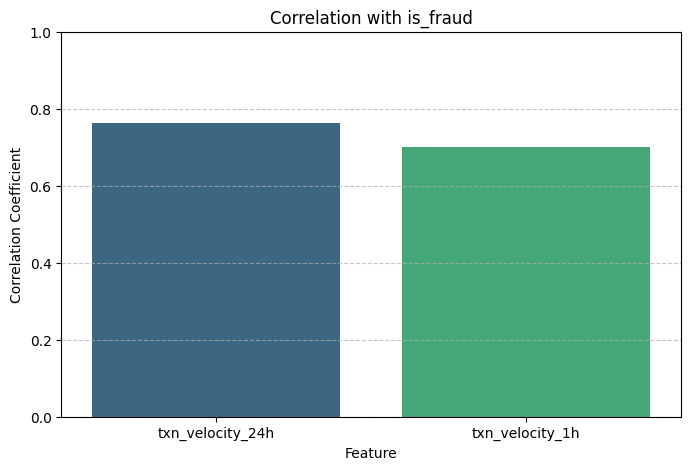

In [52]:
correlations = df.corr(numeric_only=True)['is_fraud'].loc[['txn_velocity_24h', 'txn_velocity_1h']]

plt.figure(figsize=(8, 5))
sns.barplot(x=correlations.index, y=correlations.values, hue=correlations.index, palette='viridis', legend=False)
plt.title('Correlation with is_fraud')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Feature')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Text(0, 0.5, 'Fraud Rate')

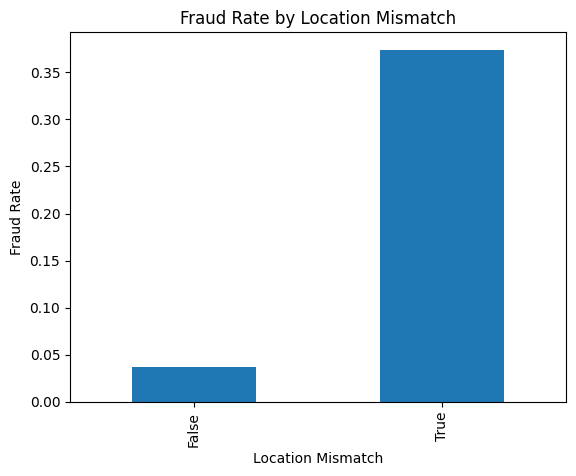

In [53]:
df.groupby('location_mismatch')['is_fraud'].mean().plot.bar()
plt.title('Fraud Rate by Location Mismatch')
plt.xlabel('Location Mismatch')
plt.ylabel('Fraud Rate')

When a location mismatch occurs, there is a very high likelihood that the transaction will be fraudulent

In [54]:
cat_columns = df.select_dtypes(include=['object', 'category']).columns
cat_columns

Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'ip_address', 'ip_country',
       'kyc_tier'],
      dtype='object')

Text(0, 0.5, 'Fraud Rate')

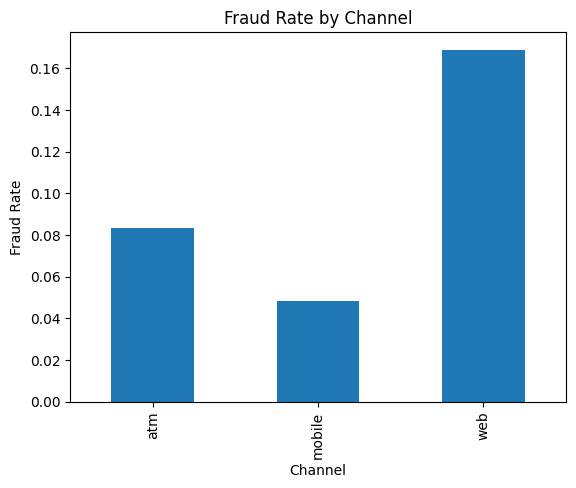

In [55]:
df.groupby('channel')['is_fraud'].mean().plot.bar()
plt.title('Fraud Rate by Channel')
plt.xlabel('Channel')
plt.ylabel('Fraud Rate')

The chart shows that the web channel has the highest fraud rate at approximately 17%, significantly higher than both ATM and mobile transactions. This suggests that online transactions are more vulnerable to fraudulent activity, possibly due to remote access, weaker identity verification, or increased exposure to cyber threats.

Text(0, 0.5, 'Fraud Rate')

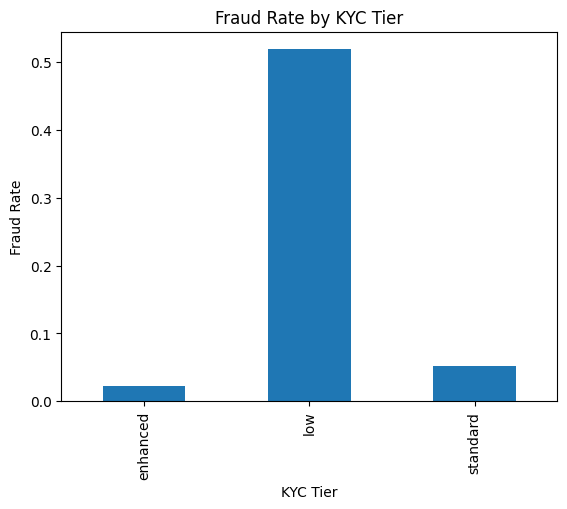

In [56]:
df.groupby('kyc_tier')['is_fraud'].mean().plot.bar()
plt.title('Fraud Rate by KYC Tier')
plt.xlabel('KYC Tier')
plt.ylabel('Fraud Rate')

Based on the plot, it appears that transactions with a 'low' KYC tier have a significantly higher fraud rate compared to 'standard' and 'enhanced' tiers. 'Standard' and 'enhanced' KYC tiers show much lower, and possibly similar, fraud rates. This suggests that a more thorough KYC process is effective in reducing the incidence of fraud.

Text(0, 0.5, 'Fraud Rate')

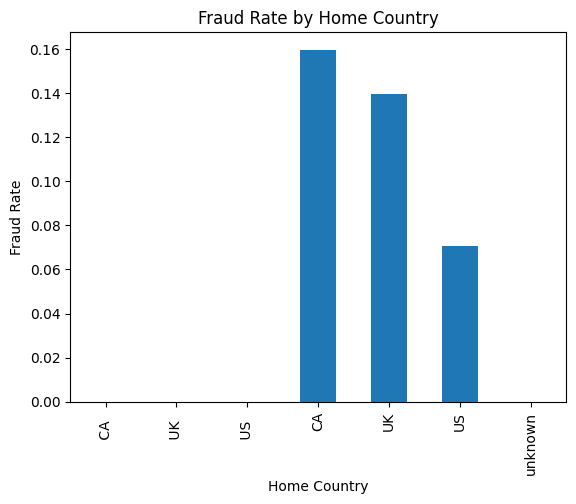

In [57]:
df.groupby('home_country')['is_fraud'].mean().plot.bar()
plt.title('Fraud Rate by Home Country')
plt.xlabel('Home Country')
plt.ylabel('Fraud Rate')

In [58]:
# Cleaning the home_country feature based on the visualization above
df['home_country'].value_counts()

,count
home_country,
US,7384
UK,1962
CA,1152
US,55
unknown,24
UK,8
CA,6


In [59]:
df['home_country'] = df['home_country'].str.strip().str.lower()
df['home_country'] = df['home_country'].replace({np.nan: 'unknown'})

In [60]:
df['home_country'].value_counts(dropna=False)

,count
home_country,
us,7439
uk,1970
ca,1158
unknown,24


Text(0, 0.5, 'Fraud Rate')

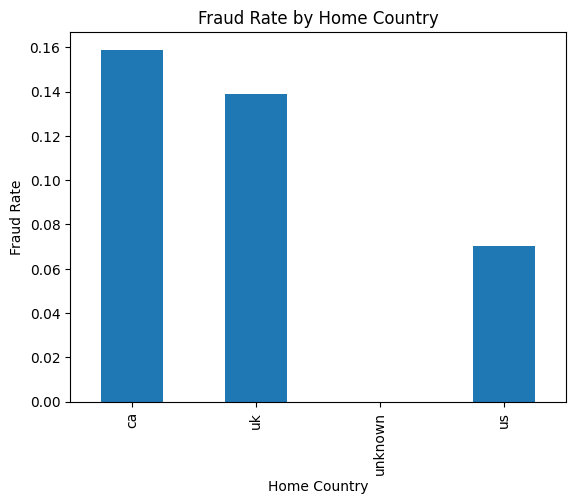

In [61]:
df.groupby('home_country')['is_fraud'].mean().plot.bar()
plt.title('Fraud Rate by Home Country')
plt.xlabel('Home Country')
plt.ylabel('Fraud Rate')

The chart shows that users from Canada (CA) and the UK have the highest fraud rates, while the US has a lower fraud rate comparatively

### Outlier Detection for Numerical Features by Fraud Status

I'll now create box plots for continuous numerical features. This will allow to visualize the distribution of these features and identify potential outliers for both fraudulent (`is_fraud = 1`) and non-fraudulent (`is_fraud = 0`) transactions. I'll start with `txn_velocity_24h` and `device_trust_score` due to their strong correlation with `is_fraud`.

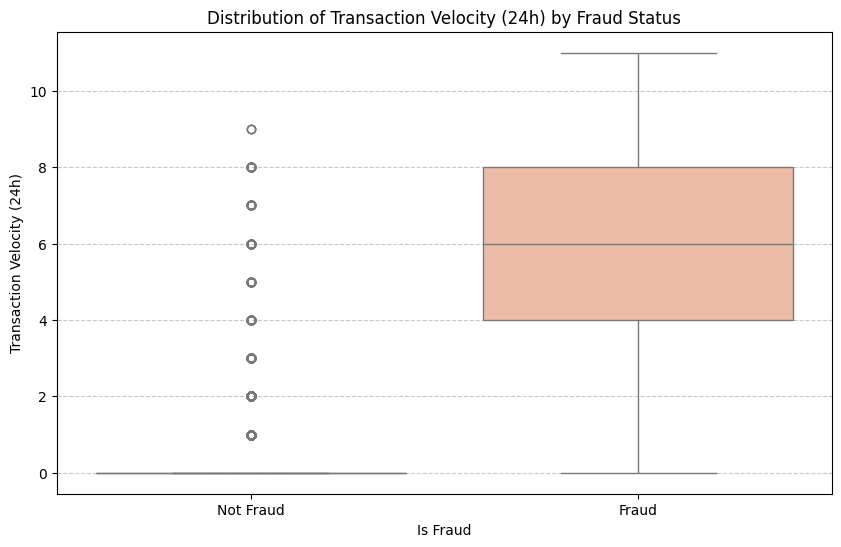

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='txn_velocity_24h', data=df, hue='is_fraud', palette='coolwarm', legend=False)
plt.title('Distribution of Transaction Velocity (24h) by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Velocity (24h)')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

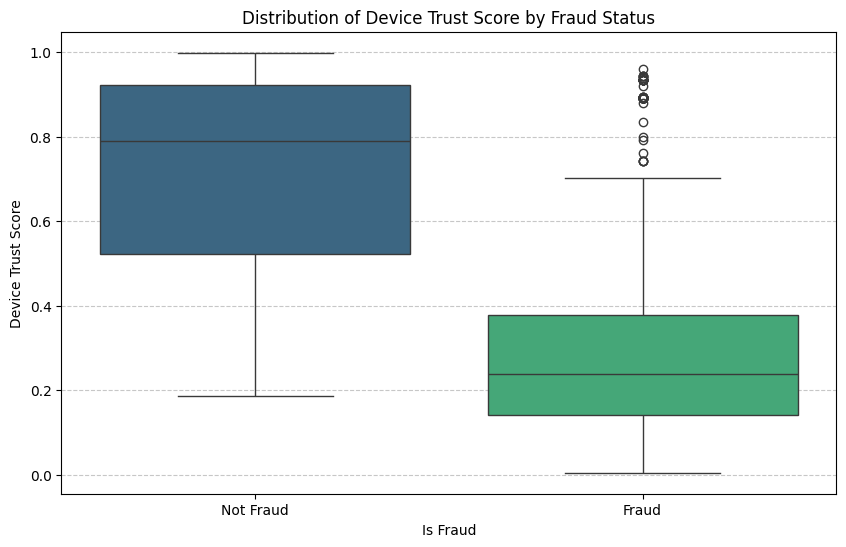

In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='device_trust_score', data=df, hue='is_fraud', palette='viridis', legend=False)
plt.title('Distribution of Device Trust Score by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Device Trust Score')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## FEATURE ENGINEERING
In this section, predictive features are generated
Time-based: hour, day of week
Amount-based:amopunt, fee, high-risk flags
Behavioural: velocity-ratiov, flags from historical behavior
Categorical: one-hot, ordinal or target encoding

Extracting the hour, day of week and weekend indicator from the timestamp column

In [64]:
# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['timestamp'].dt.weekday >= 5).astype(int)

In [65]:
df[['timestamp', 'hour', 'day_of_week', 'is_weekend']].head()

,timestamp,hour,day_of_week,is_weekend
0,2022-10-03 18:40:59.468549+00:00,18,0,0
1,2022-10-03 20:39:38.468549+00:00,20,0,0
2,2022-10-03 23:02:43.468549+00:00,23,0,0
3,2022-10-04 01:08:53.468549+00:00,1,1,0
4,2022-10-04 09:35:03.468549+00:00,9,1,0


In [66]:
print(df['hour'].value_counts())

hour
4     492
19    481
3     471
23    468
5     464
18    463
15    462
6     457
8     455
16    449
0     445
13    441
12    440
10    440
7     437
22    436
20    425
9     419
17    415
21    415
11    413
14    407
2     403
1     393
Name: count, dtype: int64


/tmp/ipykernel_3293/4014560334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='is_fraud', data=fraud_by_hour, palette='viridis')


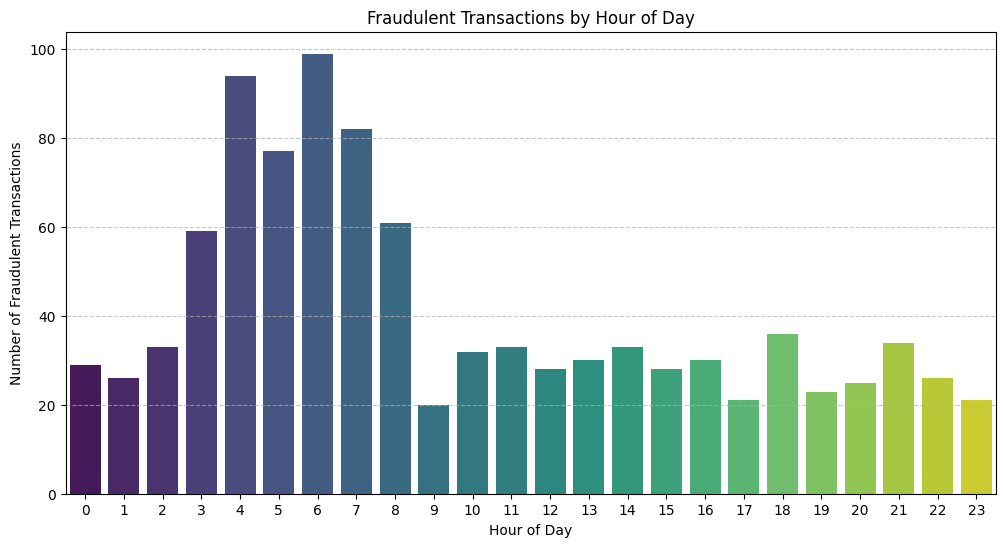

In [67]:
# Fraudulent transactions by hour of day
fraud_by_hour = df.groupby('hour')['is_fraud'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='is_fraud', data=fraud_by_hour, palette='viridis')
plt.title('Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the chart above, there seems to be a spike in the fraud rate between the early hours of the day

To visualize the fraud rate by day of the week, I will first calculate the mean fraud rate for each day and then generate a bar plot.



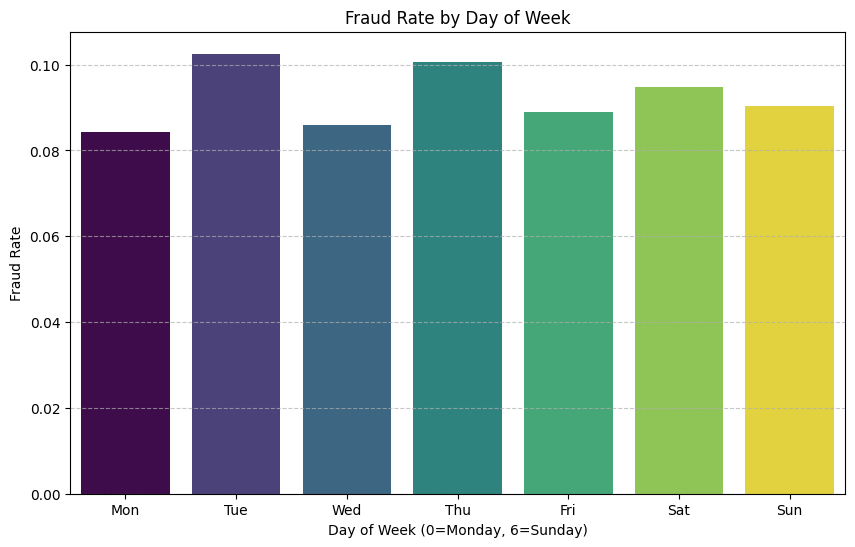

In [68]:
fraud_rate_by_day = df.groupby('day_of_week')['is_fraud'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='is_fraud', data=fraud_rate_by_day, hue='day_of_week', palette='viridis', legend=False)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Fraud Rate')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Creating account age buckets to see fraud rate by age category

  age_bucket  is_fraud
0       <30d  0.372429
1     30-90d  0.444712
2    90-180d  0.024134
3   180-365d  0.017251
4       >1yr  0.010742


/tmp/ipykernel_3293/2262090591.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_age = df.groupby('age_bucket')['is_fraud'].mean().reset_index()


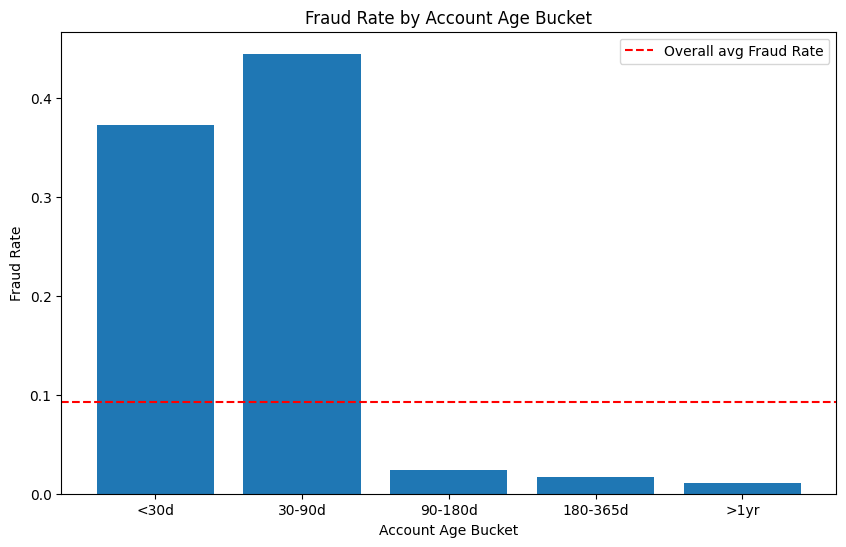

In [73]:
# Fraud rate by account age buckets
df['age_bucket'] = pd.cut(df['account_age_days'],
                          bins=[0, 30, 90, 180, 365, 2000],
                          labels=['<30d', '30-90d', '90-180d', '180-365d', '>1yr'])

fraud_rate_by_age = df.groupby('age_bucket')['is_fraud'].mean().reset_index()
print(fraud_rate_by_age)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_rate_by_age)), fraud_rate_by_age['is_fraud'].values)
plt.xticks(range(len(fraud_rate_by_age)), fraud_rate_by_age['age_bucket'])
plt.title('Fraud Rate by Account Age Bucket')
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg Fraud Rate')
plt.legend()
plt.show()

The plot shows the fraud rate across different account age buckets. It's evident that accounts less than 90 days old (<30d and 30-90d) have a significantly higher fraud rate compared to older accounts. Specifically, accounts between 30 and 90 days old show the highest fraud rate, at 44.47%, while accounts older than a year have the lowest at 1.07%. It can be inferred that newer accounts just created tend to have a higher exposure to fraud than older accounts

   txn_velocity_1h  is_fraud
0                0  0.017688
1                1  0.000000
2                2  0.000000
3                3  0.835878
4                4  0.845833
5                5  0.813830
6                6  0.708333
7                7  0.702703
8                8  0.482759


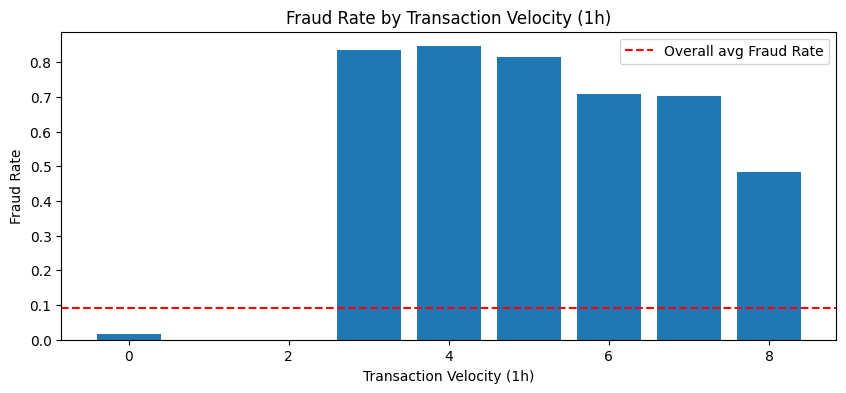

In [76]:
# Fraud rate by velocity of transactions in last hour
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean().reset_index()
print(fraud_by_velocity)

plt.figure(figsize=(10,4))
plt.bar(fraud_by_velocity['txn_velocity_1h'], fraud_by_velocity['is_fraud'])
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg Fraud Rate')
plt.legend()
plt.show()

The rate of fraud increases with high number of transactions from the graph above peaking at velocities between 3 and 5

    txn_velocity_24h  is_fraud
0                  0  0.017954
1                  1  0.016189
2                  2  0.000000
3                  3  0.042857
4                  4  0.580882
5                  5  0.795031
6                  6  0.803213
7                  7  0.814815
8                  8  0.734940
9                  9  0.964286
10                10  1.000000
11                11  1.000000


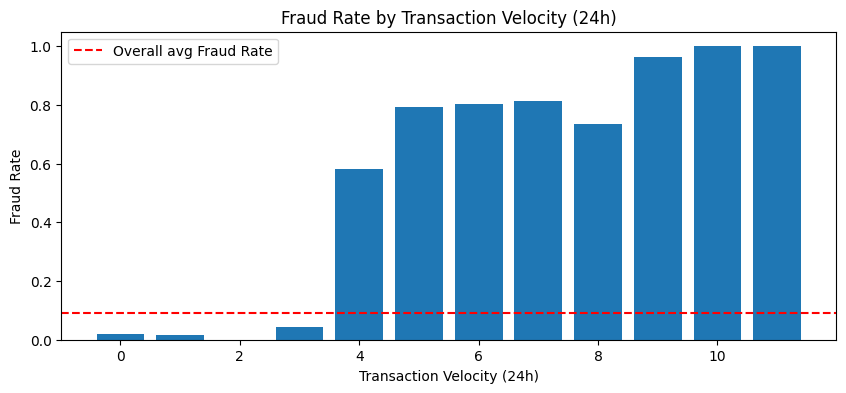

In [77]:
# Fraud rate by velocity of transactions in 24 hours
fraud_by_velocity = df.groupby('txn_velocity_24h')['is_fraud'].mean().reset_index()
print(fraud_by_velocity)

plt.figure(figsize=(10,4))
plt.bar(fraud_by_velocity['txn_velocity_24h'], fraud_by_velocity['is_fraud'])
plt.xlabel('Transaction Velocity (24h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (24h)')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg Fraud Rate')
plt.legend()
plt.show()

  amount_bucket  is_fraud
0         <$100  0.018318
1      $100-500  0.062579
2       $500-1k  0.304459
3        $1k-2k  0.689922
4        $2k-5k  0.943820
5           >5k  0.144186


/tmp/ipykernel_3293/3114589986.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_amount = df.groupby('amount_bucket')['is_fraud'].mean().reset_index()


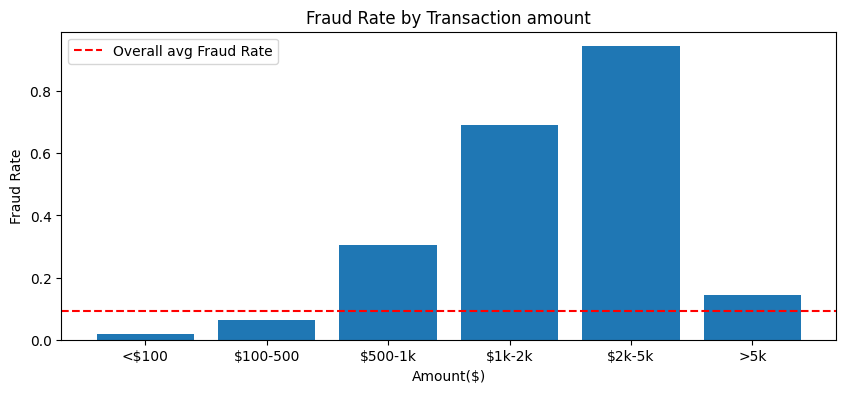

In [81]:
# Fraud rate by amount
df['amount_bucket'] = pd.cut(df['amount_usd'],
                          bins=[0, 100, 500, 1000, 2000, 5000, 20000],
                          labels=['<$100', '$100-500', '$500-1k', '$1k-2k', '$2k-5k', '>5k'])

fraud_rate_by_amount = df.groupby('amount_bucket')['is_fraud'].mean().reset_index()
print(fraud_rate_by_amount)

plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_rate_by_amount)), fraud_rate_by_amount['is_fraud'].values)
plt.xticks(range(len(fraud_rate_by_amount)), fraud_rate_by_amount['amount_bucket'])
plt.title('Fraud Rate by Transaction amount')
plt.xlabel('Amount($)')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg Fraud Rate')
plt.legend()
plt.show()

The chart above reveals that fraud rate increases as amount increases with the highest fraud rate being within $2-5k USD

/tmp/ipykernel_3293/3532172283.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_ip = df.groupby('ip_risk_score_bucket')['is_fraud'].mean()


ip_risk_score_bucket
low<0.3     0.014898
0.3-0.5     0.022612
0.5-0.7     0.030010
0.7-0.8     0.200000
High>0.8    0.629780
Name: is_fraud, dtype: float64


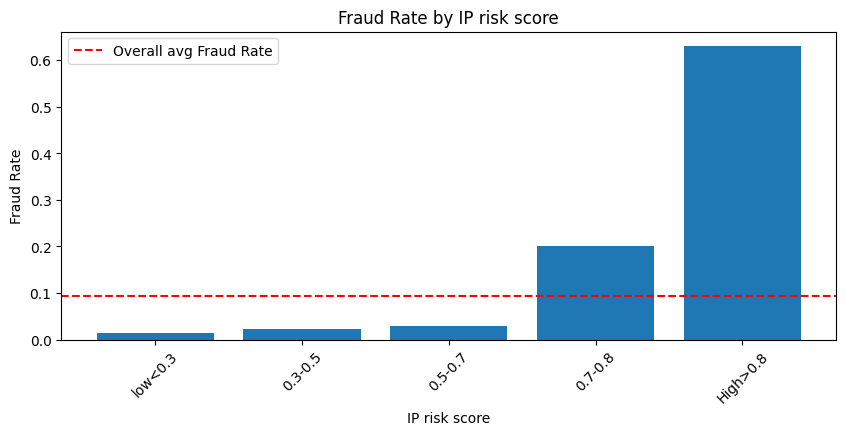

In [84]:
# Fraud rate by IP risk score bucket

df['ip_risk_score_bucket'] = pd.cut(df['ip_risk_score'],
                                    bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],
                                    labels=['low<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.8', 'High>0.8'])
fraud_by_ip = df.groupby('ip_risk_score_bucket')['is_fraud'].mean()
print(fraud_by_ip)

plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_by_ip)), fraud_by_ip.values)
plt.xticks(range(len(fraud_by_ip)), fraud_by_ip.index, rotation=45)
plt.title('Fraud Rate by IP risk score')
plt.xlabel('IP risk score')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg Fraud Rate')
plt.legend()
plt.show()

The above chart confirms that fraud rate is increased where the IP risk score is high

/tmp/ipykernel_3293/3288930694.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_device = df.groupby('device_trust_bucket')['is_fraud'].mean()


device_trust_bucket
low<0.3     0.849791
0.3-0.5     0.113793
0.5-0.7     0.020722
0.7-0.9     0.032799
High>0.9    0.008307
Name: is_fraud, dtype: float64


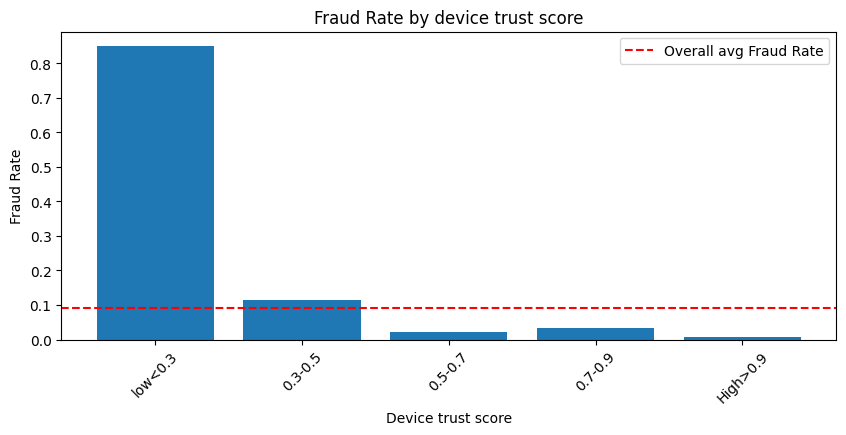

In [85]:
#Fraud rate by device trust score

df['device_trust_bucket'] = pd.cut(df['device_trust_score'],
                                    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
                                    labels=['low<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', 'High>0.9'])
fraud_by_device = df.groupby('device_trust_bucket')['is_fraud'].mean()
print(fraud_by_device)

plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_by_device)), fraud_by_device.values)
plt.xticks(range(len(fraud_by_device)), fraud_by_device.index, rotation=45)
plt.title('Fraud Rate by device trust score')
plt.xlabel('Device trust score')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg Fraud Rate')
plt.legend()
plt.show()

As expected, devices with low trust scores are more susceptible to fraud as seen from the chart above

Now, I create threshold-based features based on all the analysis above

### Threshold-based Features

Based on the insights from the exploratory data analysis, the following binary features are created to flag potential fraudulent transactions:

*   `high_velocity_1h`: Flags transactions with a high velocity in the last hour (>= 3).
*   `high_velocity_24h`: Flags transactions with a high velocity in the last 24 hours (>= 4).
*   `ip_high_risk`: Flags transactions originating from IP addresses with a high risk score (> 0.8).
*   `low_device_trust`: Flags transactions made from devices with a low trust score (< 0.5).
*   `very_new_account`: Flags transactions from accounts less than 30 days old.
*   `new_account`: Flags transactions from accounts greater or equals to 30 days old and less than 90 days old.
*   `is_web_channel`: Flags transactions made through the 'web' channel.
*   `low_kyc_tier`: Flags transactions associated with a 'low' KYC tier.
*   `risky_home_country`: Flags transactions from 'ca' or 'uk' home countries, which showed higher fraud rates.
*   `high_amount_fraud`: Flags transactions with amounts between $1k and $5k, where fraud rates peaked.
*   `location_mismatch_flag`: Directly uses the existing `location_mismatch` boolean feature, converting it to an integer.
*   `night_hours`: flags transactions that occur between the hours of 3 and 7am

In [92]:
# 1. High transaction velocity in last hour
df['high_velocity_1h'] = (df['txn_velocity_1h'] >= 3).astype(int)

# 2. High transaction velocity in last 24 hours
df['high_velocity_24h'] = (df['txn_velocity_24h'] >= 4).astype(int)

# 3. High IP risk score
df['ip_high_risk'] = (df['ip_risk_score'] > 0.8).astype(int)

# 4. Low device trust score
df['low_device_trust'] = (df['device_trust_score'] < 0.5).astype(int)

# 5. Very New account (age < 30 days)
df['very_new_account'] = (df['account_age_days'] <30).astype(int)

# 6. New account(>=30 and <90d)
df['new_account'] = ((df['account_age_days'] >=30) & (df['account_age_days'] <90)).astype(int)

# 6. Web channel usage
df['is_web_channel'] = (df['channel'] == 'web').astype(int)

# 7. Low KYC tier
df['low_kyc_tier'] = (df['kyc_tier'] == 'low').astype(int)

# 8. Risky home country
df['risky_home_country'] = df['home_country'].isin(['ca', 'uk']).astype(int)

# 9. High amount fraud (peaked between $1k and $5k)
df['high_amount_fraud'] = (df['amount_usd'] >=2000).astype(int)

# 10. Location mismatch flag (already boolean, convert to int)
df['location_mismatch_flag'] = df['location_mismatch'].astype(int)

#11. Night hours (>=3 and <=7)
df['night_hours'] = ((df['hour'] >=3 ) & (df['hour'] <=7)).astype(int)

print('Features created')
print (df[['high_velocity_1h', 'high_velocity_24h', 'ip_high_risk', 'low_device_trust', 'very_new_account',
           'new_account', 'is_web_channel', 'low_kyc_tier', 'risky_home_country',
           'high_amount_fraud', 'location_mismatch_flag', 'night_hours']].describe())

Features created
       high_velocity_1h  high_velocity_24h  ip_high_risk  low_device_trust  \
count      10591.000000       10591.000000  10591.000000      10591.000000   
mean           0.099707           0.097441      0.116042          0.232084   
std            0.299623           0.296572      0.320290          0.422182   
min            0.000000           0.000000      0.000000          0.000000   
25%            0.000000           0.000000      0.000000          0.000000   
50%            0.000000           0.000000      0.000000          0.000000   
75%            0.000000           0.000000      0.000000          0.000000   
max            1.000000           1.000000      1.000000          1.000000   

       very_new_account   new_account  is_web_channel  low_kyc_tier  \
count      10591.000000  10591.000000    10591.000000  10591.000000   
mean           0.169295      0.031631        0.340289      0.097441   
std            0.375030      0.175023        0.473829      0.296572

In [90]:
# Display the first few rows with new features
display(df[['transaction_id', 'is_fraud', 'txn_velocity_1h', 'high_velocity_1h',
            'ip_risk_score', 'high_velocity_24h', 'ip_high_risk', 'device_trust_score', 'low_device_trust',
            'account_age_days', 'very_new_account', 'new_account', 'channel', 'is_web_channel',
            'kyc_tier', 'low_kyc_tier', 'home_country', 'risky_home_country',
            'amount_usd', 'high_amount_fraud', 'location_mismatch', 'location_mismatch_flag', 'night_hours']].head())

,transaction_id,is_fraud,txn_velocity_1h,high_velocity_1h,ip_risk_score,high_velocity_24h,ip_high_risk,device_trust_score,low_device_trust,account_age_days,...,is_web_channel,kyc_tier,low_kyc_tier,home_country,risky_home_country,amount_usd,high_amount_fraud,location_mismatch,location_mismatch_flag,night_hours
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,0,0,0,0.123,0,0,0.522,0,263,...,0,standard,0,us,0,278.19,0,False,0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,0,0,0,0.569,0,0,0.475,1,947,...,1,standard,0,ca,1,154.29,0,False,0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,0,0,0,0.437,0,0,0.939,0,367,...,0,enhanced,0,us,0,160.33,0,False,0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,0,0,0,0.594,0,0,0.551,0,147,...,0,standard,0,us,0,59.41,0,False,0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,0,0,0,0.121,0,0,0.894,0,257,...,0,enhanced,0,us,0,200.96,0,False,0,0


In [94]:
df.head(3)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_high_risk,low_device_trust,very_new_account,new_account,is_web_channel,low_kyc_tier,risky_home_country,high_amount_fraud,location_mismatch_flag,night_hours
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,...,0,0,0,0,0,0,0,0,0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,...,0,1,0,0,1,0,1,0,0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,2.70,...,0,0,0,0,0,0,0,0,0,0


In [95]:
pd.set_option('display.max_columns', None)
print(df.columns.tolist())

['transaction_id', 'customer_id', 'timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week', 'is_weekend', 'age_bucket', 'amount_bucket', 'ip_risk_score_bucket', 'device_trust_bucket', 'high_velocity_1h', 'high_velocity_24h', 'ip_high_risk', 'low_device_trust', 'very_new_account', 'new_account', 'is_web_channel', 'low_kyc_tier', 'risky_home_country', 'high_amount_fraud', 'location_mismatch_flag', 'night_hours']


In [97]:
# Drop temporary bucket columns and select final features
df = df.drop(columns=['age_bucket', 'amount_bucket', 'ip_risk_score_bucket', 'device_trust_bucket'])

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10591 entries, 0 to 11399
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10591 non-null  object             
 1   customer_id                10591 non-null  object             
 2   timestamp                  10591 non-null  datetime64[ns, UTC]
 3   home_country               10591 non-null  object             
 4   source_currency            10591 non-null  object             
 5   dest_currency              10591 non-null  object             
 6   channel                    10591 non-null  object             
 7   amount_src                 10591 non-null  float64            
 8   amount_usd                 10591 non-null  float64            
 9   fee                        10591 non-null  float64            
 10  exchange_rate_src_to_dest  10591 non-null  float64            
 11  device_

In [102]:
# Define feature sets
numerical_features = ['amount_src', 'amount_usd', 'fee', 'ip_risk_score',
                      'account_age_days', 'device_trust_score', 'risk_score_internal',
                      'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend',
                        'high_velocity_1h', 'high_velocity_24h', 'ip_high_risk', 'low_device_trust',
                        'very_new_account', 'new_account', 'low_kyc_tier',
                        'night_hours', 'high_amount_fraud']

categorical_features = ['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device',
                        'ip_country', 'location_mismatch', 'kyc_tier']

# Display the lists of features
print("Numerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)

all_features = categorical_features + numerical_features

print(f"Total features: {len(all_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"df shape: {df.shape}")

Numerical Features: ['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'high_velocity_1h', 'high_velocity_24h', 'ip_high_risk', 'low_device_trust', 'very_new_account', 'new_account', 'low_kyc_tier', 'night_hours', 'high_amount_fraud']

Categorical Features: ['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier']
Total features: 30
Categorical features: 8
Numerical features: 22
df shape: (10591, 41)


## MODELLING

## Data Preparation for Modeling

In this section, I will prepare the data for machine learning models. This involves:

1.  **One-Hot Encoding**: Converting categorical features into a numerical format that machine learning algorithms can understand.
2.  **Feature Scaling**: Standardizing numerical features to ensure that no single feature dominates the learning process, which is especially important for algorithms sensitive to feature magnitudes.
3.  **Data Splitting**: Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data.
4.  **Sorting by timestamp**: Sort the dataframe chronologically to prevent data leakage.

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Sort the DataFrame by timestamp to prevent data leakage in time-series related problems
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Separate target variable
X = df[numerical_features + categorical_features]
y = df['is_fraud']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Perform a chronological split using iloc to prevent data leakage
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print("Data preparation complete!")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Display the first few rows of the preprocessed training data
display(X_train.head())

Data preparation complete!
Shape of X_train: (8472, 47)
Shape of X_test: (2119, 47)
Shape of y_train: (8472,)
Shape of y_test: (2119,)


,amount_src,amount_usd,fee,ip_risk_score,account_age_days,device_trust_score,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,hour,day_of_week,is_weekend,high_velocity_1h,high_velocity_24h,ip_high_risk,low_device_trust,very_new_account,new_account,low_kyc_tier,night_hours,high_amount_fraud,home_country_uk,home_country_unknown,home_country_us,source_currency_GBP,source_currency_USD,dest_currency_CNY,dest_currency_EUR,dest_currency_GBP,dest_currency_INR,dest_currency_MXN,dest_currency_NGN,dest_currency_PHP,dest_currency_USD,channel_mobile,channel_web,new_device_True,ip_country_ UK,ip_country_ US,ip_country_CA,ip_country_UK,ip_country_US,ip_country_unknown,location_mismatch_True,kyc_tier_low,kyc_tier_standard
0,-0.122790,-0.124751,-0.167370,-1.035403,-0.378816,-0.567360,-0.316121,-0.324829,-0.379164,-0.536991,0.936501,-1.490432,-0.621057,-0.332791,-0.328574,-0.362319,-0.549750,-0.451438,-0.180731,-0.328574,-0.529767,-0.171907,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
1,-0.173270,-0.213241,-0.167853,0.730382,1.621469,-0.751228,-0.006164,-0.324829,0.117832,-0.536991,1.225421,-1.490432,-0.621057,-0.332791,-0.328574,-0.362319,1.819007,-0.451438,-0.180731,-0.328574,-0.529767,-0.171907,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,True,False,False,False,False,False,True
2,-0.208174,-0.208927,-0.242185,0.207773,-0.074679,1.063986,-0.639854,-0.324829,-0.379164,-0.536991,1.658801,-1.490432,-0.621057,-0.332791,-0.328574,-0.362319,-0.549750,-0.451438,-0.180731,-0.328574,-0.529767,-0.171907,False,False,True,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
3,-0.281286,-0.281004,-0.265354,0.829361,-0.718045,-0.453909,0.841052,-0.324829,-0.379164,-0.536991,-1.519319,-0.989125,-0.621057,-0.332791,-0.328574,-0.362319,-0.549750,-0.451438,-0.180731,-0.328574,-0.529767,-0.171907,False,False,True,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
4,-0.178739,-0.179909,-0.198262,-1.043321,-0.396362,0.887941,-0.081931,-0.324829,-0.379164,-0.536991,-0.363639,-0.989125,-0.621057,-0.332791,-0.328574,-0.362319,-0.549750,-0.451438,-0.180731,-0.328574,-0.529767,-0.171907,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False


In [111]:
# Print number of rows, fraud counts, and fraud rates for training set
print("\n--- Training Set Statistics ---")
print(f"Number of rows: {X_train.shape[0]}")
print(f"Fraud counts:\n{y_train.value_counts()}")
print(f"Fraud rate:\n{y_train.value_counts(normalize=True)}")

# Print number of rows, fraud counts, and fraud rates for testing set
print("\n--- Testing Set Statistics ---")
print(f"Number of rows: {X_test.shape[0]}")
print(f"Fraud counts:\n{y_test.value_counts()}")
print(f"Fraud rate:\n{y_test.value_counts(normalize=True)}")


--- Training Set Statistics ---
Number of rows: 8472
Fraud counts:
is_fraud
0    7800
1     672
Name: count, dtype: int64
Fraud rate:
is_fraud
0    0.92068
1    0.07932
Name: proportion, dtype: float64

--- Testing Set Statistics ---
Number of rows: 2119
Fraud counts:
is_fraud
0    1811
1     308
Name: count, dtype: int64
Fraud rate:
is_fraud
0    0.854648
1    0.145352
Name: proportion, dtype: float64


### Explanation of Feature Count Discrepancy

The observed increase in features from 30 (22 numerical + 8 categorical) to 47 in `X_train` is due to **one-hot encoding** of the categorical variables using `pd.get_dummies(..., drop_first=True)`.

Here's how the count breaks down:
- **Numerical Features**: 22 (as defined in `numerical_features`)
- **Categorical Features (after One-Hot Encoding)**:
  - `home_country` (4 unique values) -> 3 new columns
  - `source_currency` (3 unique values) -> 2 new columns
  - `dest_currency` (9 unique values) -> 8 new columns
  - `channel` (3 unique values after cleaning/dropping 'nan') -> 2 new columns
  - `new_device` (2 unique values) -> 1 new column
  - `ip_country` (7 unique values) -> 6 new columns
  - `location_mismatch` (2 unique values) -> 1 new column
  - `kyc_tier` (3 unique values after cleaning/dropping 'nan') -> 2 new columns

Total one-hot encoded columns = 3 + 2 + 8 + 2 + 1 + 6 + 1 + 2 = **25 columns**.

Therefore, the total number of features in `X` (and consequently `X_train` and `X_test`) is 22 (numerical) + 25 (encoded categorical) = **47 features**.

## Model Training: Logistic Regression

I will now train a Logistic Regression model, a common choice for binary classification tasks. After training, I will evaluate its performance using key metrics like accuracy, precision, recall, F1-score, and a confusion matrix to understand how well it distinguishes between fraudulent and non-fraudulent transactions.

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000) # Using 'balanced' for imbalanced dataset

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Logistic Regression Model Performance ---
Accuracy: 0.9566
ROC AUC Score: 0.9834

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1811
           1       0.80      0.94      0.86       308

    accuracy                           0.96      2119
   macro avg       0.89      0.95      0.92      2119
weighted avg       0.96      0.96      0.96      2119


Confusion Matrix:
[[1736   75]
 [  17  291]]


Logistic Regression Model Summary

The Logistic Regression model demonstrated strong performance in detecting fraudulent transactions. The model achieved an accuracy of 95.66% and an excellent ROC AUC score of 0.9834, indicating a high ability to distinguish between fraudulent and legitimate transactions.

For the fraud class (Class 1), the model achieved:

Precision: 0.80
Recall: 0.94
F1-score: 0.86

The high recall shows that the model successfully detected most fraudulent transactions which is important for NovaPay

The confusion matrix further highlights the model’s effectiveness:

True Positives (TP): 291 fraud cases correctly identified
False Negatives (FN): 17 fraud cases missed
False Positives (FP): 75 legitimate transactions incorrectly flagged
True Negatives (TN): 1736 legitimate transactions correctly classified

Overall, the model provides a strong balance between fraud detection capability and minimizing false alarms

### Model Training: Random Forest Classifier

I will now train a Random Forest Classifier, which is an ensemble learning method that can handle complex relationships in the data and is generally less prone to overfitting than a single decision tree.

In [114]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced') # Using 'balanced' for imbalanced dataset

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("--- Random Forest Classifier Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

--- Random Forest Classifier Model Performance ---
Accuracy: 0.9882
ROC AUC Score: 0.9739

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1811
           1       1.00      0.92      0.96       308

    accuracy                           0.99      2119
   macro avg       0.99      0.96      0.98      2119
weighted avg       0.99      0.99      0.99      2119


Confusion Matrix:
[[1811    0]
 [  25  283]]


Random Forest Classifier Summary

The Random Forest Classifier demonstrated outstanding performance in detecting fraudulent transactions, achieving an accuracy of 98.82% and a strong ROC AUC score of 0.9739. The model showed excellent classification capability with particularly strong precision for fraud detection.

For the fraud class (Class 1), the model achieved:

Precision: 1.00
Recall: 0.92
F1-score: 0.96

The perfect precision indicates that every transaction predicted as fraudulent was actually fraud, resulting in zero false positives. This is highly valuable for NovaPay, as it avoids incorrectly flagging legitimate customer transactions.

The confusion matrix results were:

True Positives (TP): 283 fraud cases correctly detected
False Negatives (FN): 25 fraud cases missed
False Positives (FP): 0 legitimate transactions incorrectly flagged
True Negatives (TN): 1811 legitimate transactions correctly classified

### Model Comparison: Logistic Regression vs. Random Forest

When comparing the Logistic Regression and Random Forest models for fraud detection, key differences in precision and recall for the fraud class (Class 1) emerge:

*   **Logistic Regression:**
    *   **Precision (Fraud): 0.80**
    *   **Recall (Fraud): 0.94**
    *   This model achieved higher recall for fraud, meaning it caught more actual fraudulent transactions (missed fewer frauds). However, it had lower precision, resulting in more false positives (legitimate transactions incorrectly flagged as fraud).

*   **Random Forest Classifier:**
    *   **Precision (Fraud): 1.00**
    *   **Recall (Fraud): 0.92**
    *   The Random Forest model demonstrated perfect precision for fraud, indicating **zero false positives**. This is highly valuable in practice as it avoids inconveniencing legitimate customers. Its recall was slightly lower than Logistic Regression's, meaning it missed a few more actual fraudulent transactions (25 vs. 17), but the trade-off of no false positives might be preferable depending on the business context.

In summary, if the priority is to minimize false positives and avoid flagging legitimate customers, the **Random Forest Classifier** is the superior choice due to its perfect precision for the fraud class. If catching every possible fraud is paramount, even at the cost of more false alarms, the Logistic Regression model's slightly higher recall might be preferred, though its precision is significantly lower.

### Feature Importance with SHAP (SHapley Additive exPlanations)

To better understand which features are most influential in our Random Forest Classifier's predictions, i will use SHAP (SHapley Additive exPlanations). SHAP values provide a unified measure of feature importance, indicating how much each feature contributes to the prediction for each individual instance. This helps interpret the model's output in a more transparent way.

In [115]:
!pip install shap

In [116]:
import shap

# Create a SHAP TreeExplainer for the Random Forest model
# TreeExplainer is optimized for tree-based models like RandomForestClassifier
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# We convert X_test to a DataFrame if it's not already, to keep feature names
shap_values = explainer.shap_values(X_test)

# shap_values will be a list of arrays (one for each class). For binary classification,
# shap_values[1] typically corresponds to the positive class (fraud).
print("SHAP values calculated.")

SHAP values calculated.


#### SHAP Summary Plot

The summary plot combines feature importance with feature effects. Each point on the plot represents a Shapley value for a feature and an instance:
- **Position on the x-axis**: Represents the impact of that feature on the model's output prediction.
- **Color**: Represents the feature value (red means higher, blue means lower).
- **Vertical spread**: Indicates the distribution of Shapley values for that feature across the dataset, showing the range of impacts.

This plot helps identify which features are most important overall (features ordered from top to bottom) and how their values affect the prediction (e.g., high values of feature X tend to increase the fraud prediction).

SHAP Interpretation for Feature Importance
SHAP (SHapley Additive exPlanations) helps explain how each feature contributes to the model’s fraud predictions. It provides both the importance of features and the direction of their impact on fraud risk.
The SHAP analysis showed that the most influential features in predicting fraud were:


txn_velocity_24h


txn_velocity_1h


risk_score_internal


ip_risk_score


chargeback_history_count


Higher values for these features generally increased the likelihood of a transaction being classified as fraudulent. This indicates that rapid transaction activity, risky IP behavior, and previous chargeback history are strong fraud indicators.
Features such as:


device_trust_score


account_age_days


had negative SHAP impacts, meaning higher values reduced fraud probability. Older accounts and trusted devices were associated with more legitimate behavior.
The SHAP plots also highlighted that behavioral and risk-based features contributed more to model decisions than transaction amount features like amount_usd or fee, suggesting that fraud detection at NovaPay relies more on suspicious activity patterns than transaction size alone.
Overall, SHAP analysis improved the interpretability of the model by clearly identifying which features most influenced fraud predictions and how they affected decision outcomes.